# Vision Transformer（ViT）從零開始：CIFAR-10 RGB 圖像分類
### *An Image is Worth 16×16 Words* — a from-scratch, training-first tour

本筆記本逐層手刻論文 **"An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale"** (Dosovitskiy et al., ICLR 2021) 的 Vision Transformer，並在 **RGB 的 CIFAR-10** 上**從零開始訓練**。重點放在**模型結構**——每個張量怎麼流動、每個設計選擇為何如此。

> **這是理解 DINO / cellDINO 的基石。** 本筆記本只談「基本 ViT」（忠於原論文）；DINO 的自監督部分留到另一本筆記本。我們在這裡刻意採用論文原版的 `[CLS]` token 與可學習位置編碼，因為那正是 DINO backbone 的形狀。

#### 設計決策（design tree，已定案）
| 決策 | 選擇 | 理由 |
|---|---|---|
| Dataset | CIFAR-10 (32×32 RGB) | 從零訓練 ViT 的標準教學資料集；patch 4 → 64 tokens |
| 架構 | 論文原版：`[CLS]` + 可學習 1D 位置編碼 + Pre-LN + GELU | 即 DINO backbone 形狀 |
| 規模 | Tiny：dim 192 / depth 6 / heads 3 / MLP×4（~2–3M） | 在 Mac MPS 上「看得到它學起來」 |
| 訓練 | AdamW + warmup→cosine、RandAugment + crop/flip + label smoothing | ViT 無歸納偏好，靠資料增強補足 |
| 分析 | 結構+shape trace · patch/濾波器 PCA · attention rollout · 位置編碼/注意力距離 | 1:1 對應論文 Fig 6 & 7 |

#### ⚠️ 論文的核心教訓（§4.3, Fig 3/4）
ViT **缺乏 CNN 的歸納偏好**（局部性 locality、平移等變性 translation equivariance）。因此**在小資料上從零訓練會輸給同規模的 CNN**。我們用強資料增強去逼近一個堪用的模型（~75–80%），但請把這個「資料飢渴」現象本身當成一個重要觀察——它正是後續需要大規模（自）監督預訓練（如 DINO）的動機。

## 1. 環境與裝置 / Setup & device
我們用 PyTorch + MPS（Apple Silicon GPU）。`SMOKE` 旗標供自動化煙霧測試使用（少量資料 + 1 epoch）；正常使用時忽略即可。

In [1]:
# %pip install einops vit-pytorch scikit-learn --quiet   # 若環境缺套件，取消註解執行一次
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ── 繁體中文字型支援 / Traditional-Chinese font for matplotlib ──
# 圖中含中文標題，預設 DejaVu Sans 無 CJK 字符，會顯示成空方框（tofu）。
# 自動挑一個系統已安裝的中文字型（優先繁體），找不到才退回預設並提示。
_cjk_candidates = ["PingFang TC", "PingFang HK", "Heiti TC", "Noto Sans CJK TC",
                   "Noto Sans TC", "Microsoft JhengHei", "Arial Unicode MS",
                   "Hiragino Sans GB", "STHeiti", "PingFang SC", "SimHei"]
_avail = {f.name for f in font_manager.fontManager.ttflist}
_cjk_font = next((f for f in _cjk_candidates if f in _avail), None)
if _cjk_font:
    plt.rcParams["font.sans-serif"] = [_cjk_font] + plt.rcParams.get("font.sans-serif", [])
    plt.rcParams["axes.unicode_minus"] = False          # 用 ASCII 減號，避免負號變方框
    print("中文字型 / CJK font:", _cjk_font)
else:
    print("⚠️ 找不到中文字型，圖中中文可能顯示為方框；macOS 內建 PingFang，"
          "或 `pip install` 一個含 CJK 的字型後重跑此 cell")

torch.manual_seed(0); np.random.seed(0)

SMOKE = os.environ.get("VIT_SMOKE", "0") == "1"   # 煙霧測試：少量資料 + 1 epoch

def get_device():
    if torch.backends.mps.is_available(): return torch.device("mps")
    if torch.cuda.is_available():         return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Device:", DEVICE, "| SMOKE:", SMOKE)

中文字型 / CJK font: PingFang HK
Device: mps | SMOKE: False


## 2. 超參數設定 / Configuration
所有結構與訓練超參數集中在這裡，方便你調整。

序列長度 = `(image/patch)² + 1`。CIFAR 是 32×32，patch=4 → 8×8 = **64 個 patch token**，再加 1 個 `[CLS]` → 序列長度 **65**。注意力成本是 **O(序列長度²)**，所以 patch size 是訓練速度的最大旋鈕。

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    # ── 資料 ──
    image_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    num_classes: int = 10
    # ── 模型結構 ──
    dim: int = 192          # D：Transformer 隱藏維度（latent size），整條網路保持不變
    depth: int = 6          # L：Encoder block 層數
    heads: int = 3          # 注意力頭數（head_dim = dim/heads = 64）
    mlp_ratio: int = 4      # MLP 隱藏層 = dim * mlp_ratio
    dropout: float = 0.1
    # ── 訓練 ──
    batch_size: int = 128
    epochs: int = 50
    lr: float = 3e-4
    weight_decay: float = 0.05
    warmup_epochs: int = 5
    label_smoothing: float = 0.1

cfg = Config()
if SMOKE:
    cfg.epochs = 1; cfg.warmup_epochs = 0

cfg.num_patches = (cfg.image_size // cfg.patch_size) ** 2
cfg.head_dim    = cfg.dim // cfg.heads
cfg.grid        = cfg.image_size // cfg.patch_size
print(cfg)
print(f"num_patches={cfg.num_patches} | seq_len(+CLS)={cfg.num_patches+1} | head_dim={cfg.head_dim} | grid={cfg.grid}x{cfg.grid}")

Config(image_size=32, patch_size=4, in_channels=3, num_classes=10, dim=192, depth=6, heads=3, mlp_ratio=4, dropout=0.1, batch_size=128, epochs=50, lr=0.0003, weight_decay=0.05, warmup_epochs=5, label_smoothing=0.1)
num_patches=64 | seq_len(+CLS)=65 | head_dim=64 | grid=8x8


## 3. 資料 / CIFAR-10 with augmentation
訓練增強：`RandomCrop(padding=4)` + `RandomHorizontalFlip` + `RandAugment` + 標準化。
測試只做標準化。**RandAugment 必須作用在 `ToTensor` 之前**（它吃 PIL 影像）。

> 為什麼這麼重視增強？因為 ViT 沒有 CNN 的局部性先驗，50k 張小圖很容易被它「背起來」。增強是把多樣性硬塞進資料分布，逼模型學到可泛化的模式。

In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)
if SMOKE:
    train_set = Subset(train_set, range(1024))
    test_set  = Subset(test_set,  range(512))

CLASSES = ("plane","car","bird","cat","deer","dog","frog","horse","ship","truck")
nw = 0 if SMOKE else 2
train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,  num_workers=nw, drop_last=True)
test_loader  = DataLoader(test_set,  batch_size=cfg.batch_size, shuffle=False, num_workers=nw)
print("train batches:", len(train_loader), "| test batches:", len(test_loader))

/Users/adamw/tutorials/llm_tutorial/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train batches: 390 | test batches: 79


### 3.1 看一批增強後的樣本

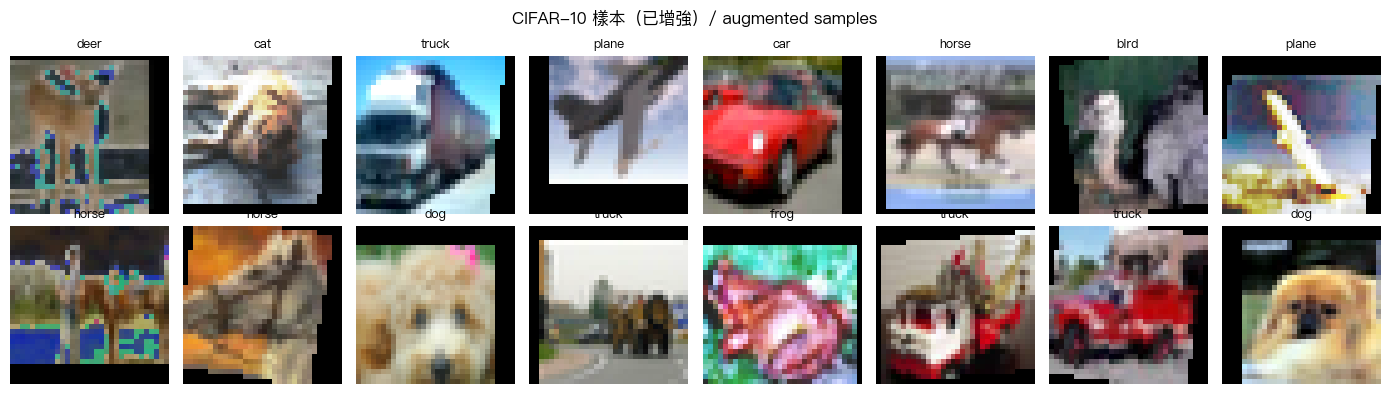

In [4]:
def denorm(t):
    # (C,H,W) 標準化張量 -> (H,W,C) in [0,1]，供顯示
    mean = torch.tensor(CIFAR_MEAN).view(3,1,1); std = torch.tensor(CIFAR_STD).view(3,1,1)
    return (t.cpu()*std + mean).clamp(0,1).permute(1,2,0).numpy()

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14,4))
for ax, img, lb in zip(axes.flatten(), imgs, labels):
    ax.imshow(denorm(img)); ax.set_title(CLASSES[lb], fontsize=9); ax.axis("off")
plt.suptitle("CIFAR-10 樣本（已增強）/ augmented samples"); plt.tight_layout(); plt.show()

## 4. 把圖切成 patch / Patchify
ViT 的第一步：把 $\mathbf{x}\in\mathbb{R}^{H\times W\times C}$ 切成 $N=HW/P^2$ 個 $P\times P$ patch，攤平成序列。下圖把一張 32×32 圖切成 8×8 = 64 個 4×4 patch——這 64 個 patch 之後就是 Transformer 的「token」（等同 NLP 的「word」）。

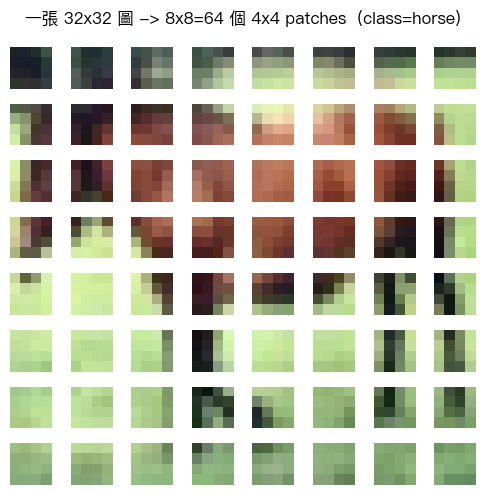

In [5]:
raw = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transforms.ToTensor())
img0, lb0 = raw[7]
P, G = cfg.patch_size, cfg.grid
fig, axes = plt.subplots(G, G, figsize=(5,5))
for i in range(G):
    for j in range(G):
        patch = img0[:, i*P:(i+1)*P, j*P:(j+1)*P]
        axes[i,j].imshow(patch.permute(1,2,0).numpy()); axes[i,j].axis("off")
plt.suptitle(f"一張 {cfg.image_size}x{cfg.image_size} 圖 -> {G}x{G}={cfg.num_patches} 個 {P}x{P} patches  (class={CLASSES[lb0]})")
plt.tight_layout(); plt.show()

### 4.1 圖解：從圖到序列 / patchify → flatten
下圖把上面的概念整理成一張示意：左邊是 32×32 影像被切成 8×8 個 patch 並依 **raster order**（由左到右、由上到下）編號；右邊是把這 64 個 patch 攤平成一條長度 64 的 token 序列。這一步就是 ViT 把「2D 影像」轉成「1D token 序列」的關鍵——之後的 Transformer 完全照 NLP 的方式處理它。

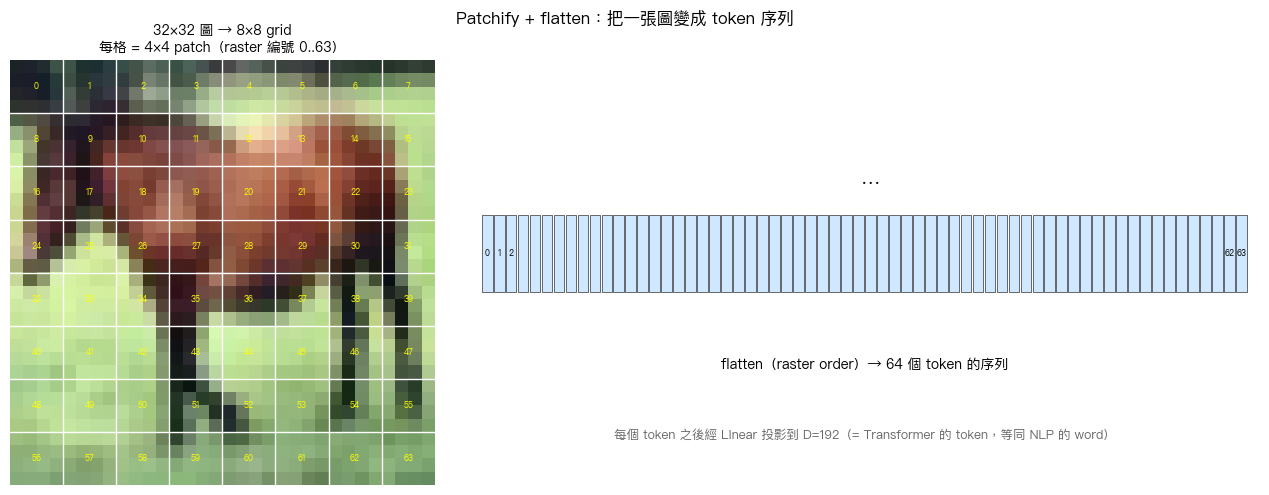

In [6]:
sample = raw[7][0]                        # (3,32,32) in [0,1]，raw 於 §4 載入
G, P, N = cfg.grid, cfg.patch_size, cfg.num_patches

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.7]})

# ── 左：原圖 + patch 格線 + raster 編號 ──
axL.imshow(sample.permute(1, 2, 0).numpy())
for k in range(1, G):
    axL.axhline(k*P - 0.5, color="w", lw=1); axL.axvline(k*P - 0.5, color="w", lw=1)
for idx in range(N):
    r, c = divmod(idx, G)
    axL.text(c*P + P/2 - 0.5, r*P + P/2 - 0.5, str(idx), color="yellow",
             ha="center", va="center", fontsize=6)
axL.set_title(f"{cfg.image_size}×{cfg.image_size} 圖 → {G}×{G} grid\n每格 = {P}×{P} patch（raster 編號 0..{N-1}）", fontsize=10)
axL.axis("off")

# ── 右：攤平成 1D token 序列 ──
axR.axis("off"); axR.set_xlim(-1, N + 1); axR.set_ylim(-2.5, 3)
for idx in range(N):
    axR.add_patch(plt.Rectangle((idx, 0), 0.9, 1, facecolor="#cfe8ff", edgecolor="black", lw=0.4))
for idx in [0, 1, 2, N - 2, N - 1]:
    axR.text(idx + 0.45, 0.5, idx, ha="center", va="center", fontsize=6)
axR.text((N - 2)/2 + 1.5, 1.4, "…", fontsize=14, ha="center")
axR.text(N/2, -1.0, f"flatten（raster order）→ {N} 個 token 的序列", ha="center", fontsize=10)
axR.text(N/2, -1.9, f"每個 token 之後經 Linear 投影到 D={cfg.dim}（= Transformer 的 token，等同 NLP 的 word）",
         ha="center", fontsize=9, color="dimgray")

plt.suptitle("Patchify + flatten：把一張圖變成 token 序列", fontsize=12)
plt.tight_layout(); plt.show()

## 5. Patch Embedding（Eq. 1 的線性投影）
論文用一個可訓練線性投影 $\mathbf{E}\in\mathbb{R}^{(P^2\cdot C)\times D}$ 把每個攤平的 patch 映到 $D$ 維。

**實作技巧**：`kernel=stride=P` 的 `Conv2d` 與「攤平 patch 再做 Linear」**數學等價**——非重疊卷積就是每個 patch 各做一次線性投影。這也是 DINO/timm 的標準寫法。

**(A) 論文原本的做法（先攤平 patch，再用 Linear 投影到 $D$）**：
$$\text{(B, 3, 32, 32)} \xrightarrow[\text{8×8=64 個 patch}]{\text{切塊}} \text{(B, 64, }\underbrace{4\times4\times3}_{=48}\text{)} \xrightarrow[\;\mathbf{E}:\,48\to192\;]{\text{Linear}} \text{(B, 64, 192)}$$

**(B) 我們的實作（等價地用一個非重疊 `Conv2d` 一步到位）**：
$$\text{(B, 3, 32, 32)} \xrightarrow{\text{Conv2d(k=s=4)}} \text{(B, 192, 8, 8)} \xrightarrow{\text{flatten+transpose}} \text{(B, 64, 192)}$$

> **兩條路為什麼等價？** (A) 把每個 patch 攤平成 $48$ 維向量、再乘上同一個矩陣 $\mathbf{E}\in\mathbb{R}^{48\times192}$；(B) 的 `Conv2d(k=s=4)` 因為**不重疊**，每個卷積核掃過一個 patch 做的正是「$48$ 個輸入值的加權和」——和 (A) 的矩陣乘法是同一筆運算，只是 PyTorch 用卷積把「切塊 + 攤平 + Linear」三步融合成一行。差別只在資料擺放：(A) 中途出現 $(B,64,48)$，(B) 中途是 $(B,192,8,8)$，最後都收斂到 $(B,64,192)$。

> **關於 `D = 192`（我們想要的 output dimension）**
> `Conv2d` 的 `out_channels` 就是嵌入維度 `D`，這裡設為 **192**——它是**我們自選的超參數**（模型的「工作寬度」），代表「每個 patch 最後要用幾維向量描述」。`out_channels=192` 等於準備 **192 個獨立卷積核**，每個核掃過一個 patch 吐出 1 個數字 → 每個 patch 得到 192 維向量；每個核是一組 $3\times4\times4=48$ 個可學權重（把原始 48 維 patch 線性投影到 192 維）。
>
> - **`192` 從何而來？** 由 attention 的設計決定：`D = heads × head_dim = 3 × 64 = 192`。Multi-Head Attention 會把 `D` 平均切給每個 head（`192/3 = 64`），所以 **`D` 必須能被 `heads` 整除**。ViT-Base 則是 `12 × 64 = 768`。
> - **它和輸入幾何無關**：`192` ≠「64 個 patch × 3 channel」（那只是數字巧合）。改 patch size 會讓 patch 數變動（如 patch=8 → 16 個 patch），但 `D` 不會跟著變——`D` 只由 `heads × head_dim` 決定。
> - **輸出 `(B, 64, 192)` 兩個維度的來源要分清**：`64` 由**輸入幾何算出**（$(32/4)^2$，「有幾個 patch」）；`192` 由**設計選定**（「每個 patch 幾維」）。

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, dim):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):           # x: (B, C, H, W)
        x = self.proj(x)            # (B, D, H/P, W/P)
        x = x.flatten(2)            # (B, D, num_patches)
        x = x.transpose(1, 2)       # (B, num_patches, D)
        return x

pe = PatchEmbedding(cfg.image_size, cfg.patch_size, cfg.in_channels, cfg.dim)
print("PatchEmbedding 輸出:", tuple(pe(torch.randn(2,3,32,32)).shape), " # (B, num_patches, D)")

PatchEmbedding 輸出: (2, 64, 192)  # (B, num_patches, D)


## 6. Multi-Head Self-Attention（注意力的數學核心）
每個 token 投影出 query / key / value，注意力是縮放點積後的 softmax 加權：
$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$
- **多頭**：把 $D$ 切成 `heads` 份（每份 `head_dim=64`），各自獨立做注意力再拼回，讓模型同時關注不同子空間。
- **$\sqrt{d_k}$ 縮放**：避免點積隨維度變大而把 softmax 推到飽和區、梯度消失。
- **全域性**：每個 token 都能看到所有 token——這就是 ViT 「沒有局部性先驗」的來源（與 CNN 的局部感受野相反）。

我們加一個 `store_attn` 旗標，需要時保存注意力權重，供後面 rollout / 注意力距離分析使用。

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads, self.head_dim = heads, dim // heads
        self.scale = self.head_dim ** -0.5
        self.qkv  = nn.Linear(dim, dim * 3)     # 一次算出 Q,K,V
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.store_attn = False
        self.last_attn = None
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]                 # 各為 (B, heads, N, head_dim)
        attn = (q @ k.transpose(-2,-1)) * self.scale     # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        if self.store_attn: self.last_attn = attn.detach()
        out = (self.drop(attn) @ v)                      # (B, heads, N, head_dim)
        out = out.transpose(1,2).reshape(B, N, D)        # 拼回各 head
        return self.proj(out)

### 6.1 圖解：Multi-Head Attention 的資料流
把上面 `MultiHeadAttention` 的 `forward` 畫成示意圖：一次 `Linear` 算出 Q/K/V，reshape 成 `H` 個 head，每個 head 各自在 `head_dim` 維的子空間做 scaled dot-product attention，最後 `concat` 回 `D` 維再經一個輸出投影。對照程式碼裡的 `reshape(B, N, 3, heads, head_dim).permute(...)` 就是在做「切 head」這件事。

> **圖中的序列長度 `65` 從哪來？** `65 = 64 個 patch + 1 個 [CLS]`。`[CLS]` 是一個額外的彙整 token，要到 **§9 組裝完整 ViT** 才會被前置到序列最前（`torch.cat([cls, x])`）；這裡先用最終形狀 `65` 畫，是為了和後面所有圖一致。
>
> **重點**：`MultiHeadAttention` 本身**對序列長度完全無感**——`forward` 第一行就是 `B, N, D = x.shape`，序列是 64 還是 65 它都照同一套算。`[CLS]` 在 attention 眼中只是序列裡多出來的一個 token，和 patch token 一視同仁。所以這個數字是 64 還是 65 不影響你理解這張圖。

/var/folders/8b/8kqdzlwx5j1f14cwsq73fx9w0000gn/T/ipykernel_24269/1713643335.py:27: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) PingFang HK.
  plt.tight_layout(); plt.show()
/Users/adamw/tutorials/llm_tutorial/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) PingFang HK.
  fig.canvas.print_figure(bytes_io, **kw)


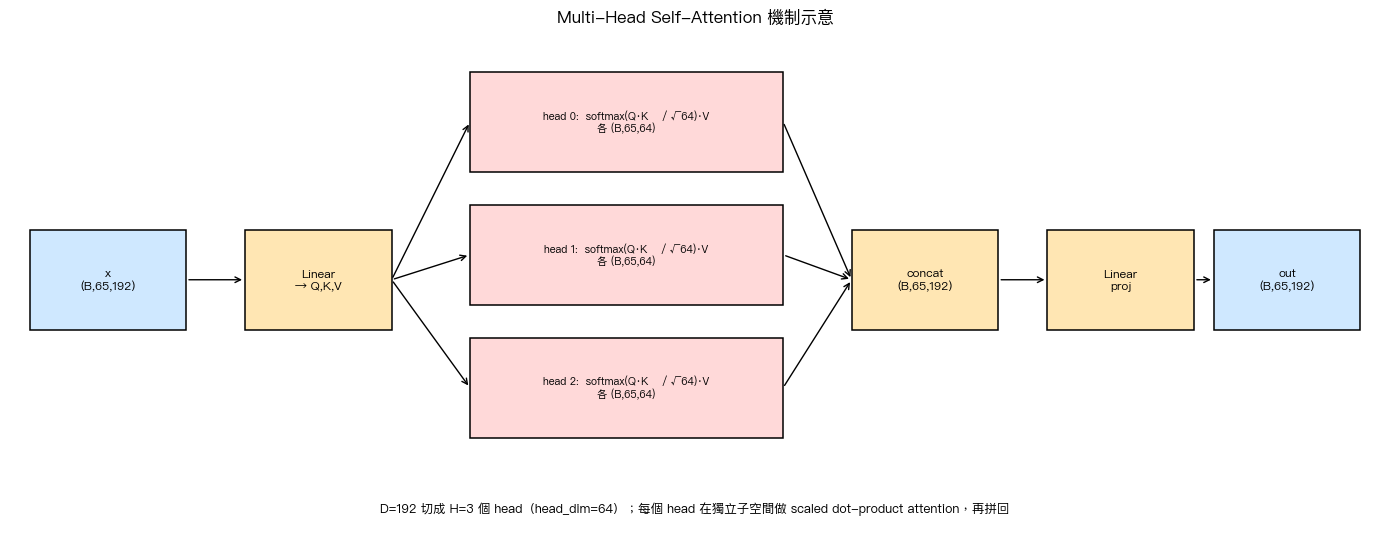

In [10]:
fig, ax = plt.subplots(figsize=(14, 5.5)); ax.axis("off")
ax.set_xlim(0, 14); ax.set_ylim(0, 6)
N, D, H, hd = cfg.num_patches + 1, cfg.dim, cfg.heads, cfg.head_dim

def box(x, y, w, h, t, c, fs=8.5):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=c, edgecolor="black", lw=1.1))
    ax.text(x+w/2, y+h/2, t, ha="center", va="center", fontsize=fs)

def arr(x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", lw=1))

box(0.2,  2.4, 1.6, 1.2, f"x\n(B,{N},{D})",       "#cfe8ff"); arr(1.8, 3, 2.4, 3)
box(2.4,  2.4, 1.5, 1.2, "Linear\n→ Q,K,V",        "#ffe6b3")
ys = [4.3, 2.7, 1.1]
for h in range(H):
    box(4.7, ys[h], 3.2, 1.2, f"head {h}:  softmax(Q·Kᵀ / √{hd})·V\n各 (B,{N},{hd})", "#ffd9d9", fs=7.5)
    arr(3.9, 3, 4.7, ys[h] + 0.6)
box(8.6,  2.4, 1.5, 1.2, f"concat\n(B,{N},{D})",   "#ffe6b3")
for h in range(H):
    arr(7.9, ys[h] + 0.6, 8.6, 3)
box(10.6, 2.4, 1.5, 1.2, "Linear\nproj",           "#ffe6b3"); arr(10.1, 3, 10.6, 3)
box(12.3, 2.4, 1.5, 1.2, f"out\n(B,{N},{D})",      "#cfe8ff"); arr(12.1, 3, 12.3, 3)

ax.text(7, 0.2, f"D={D} 切成 H={H} 個 head（head_dim={hd}）；每個 head 在獨立子空間做 scaled dot-product attention，再拼回",
        ha="center", fontsize=9)
plt.title("Multi-Head Self-Attention 機制示意", fontsize=12)
plt.tight_layout(); plt.show()

## 7. Feed-Forward（MLP block）
每個 token 獨立通過兩層 MLP（先升維 ×4 再降回），中間是 **GELU**（論文指定）。注意力負責 token 之間「混資訊」，MLP 負責每個 token 內部「做非線性變換」。

In [11]:
class FeedForward(nn.Module):
    def __init__(self, dim, mlp_ratio, dropout=0.0):
        super().__init__()
        hidden = dim * mlp_ratio                          # 本範例：192 * 4 = 768（中間層放大 mlp_ratio 倍）
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),   # 升維 192 → 768，再過 GELU 非線性
            nn.Linear(hidden, dim), nn.Dropout(dropout),             # 降回 768 → 192（維持 D 不變，才能殘差相加）
        )
        # 維度流動（本範例 D=192, mlp_ratio=4）： (B, 65, 192) → (B, 65, 768) → (B, 65, 192)
        #   · 只有最後一維 D 在「胖一下又縮回」；token 數 65 全程不變
        #   · 65 個 token 各自獨立通過、共享同一組權重（Linear 只認最後一維）
    def forward(self, x): return self.net(x)

## 8. Transformer Encoder Block（Pre-LN + 殘差）
論文用 **Pre-LN**：LayerNorm 放在子層**之前**，殘差連接在之後（Eq. 2, 3）：
$$\mathbf{z}'_\ell=\text{MSA}(\text{LN}(\mathbf{z}_{\ell-1}))+\mathbf{z}_{\ell-1},\qquad
\mathbf{z}_\ell=\text{MLP}(\text{LN}(\mathbf{z}'_\ell))+\mathbf{z}'_\ell$$
Pre-LN 讓殘差路徑保持「乾淨」的恆等映射，深層 Transformer 才能穩定訓練（這也是現代 ViT/LLM 的標準做法，與原始 Transformer 的 Post-LN 不同）。

In [12]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim); self.attn = MultiHeadAttention(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim); self.mlp  = FeedForward(dim, mlp_ratio, dropout)
    def forward(self, x):
        # 第一次殘差連結
        x = x + self.attn(self.norm1(x))   # z'_l = MSA(LN(z_{l-1})) + z_{l-1}
        # 第二次殘差連結
        x = x + self.mlp(self.norm2(x))    # z_l  = MLP(LN(z'_l))   + z'_l
        return x

### 8.1 圖解：單個 Encoder block 內部結構
把 `TransformerEncoderBlock.forward` 的兩行畫成方塊圖。注意 **LayerNorm 在子層之前**（Pre-LN），藍色弧線是兩條**殘差捷徑**：`z' = MSA(LN(z)) + z` 與 `z_out = MLP(LN(z')) + z'`。殘差讓梯度有一條「乾淨」的恆等路徑直通到底，是深層 Transformer 能穩定訓練的關鍵。整個 ViT 就是把這個 block 疊 `depth` 次。

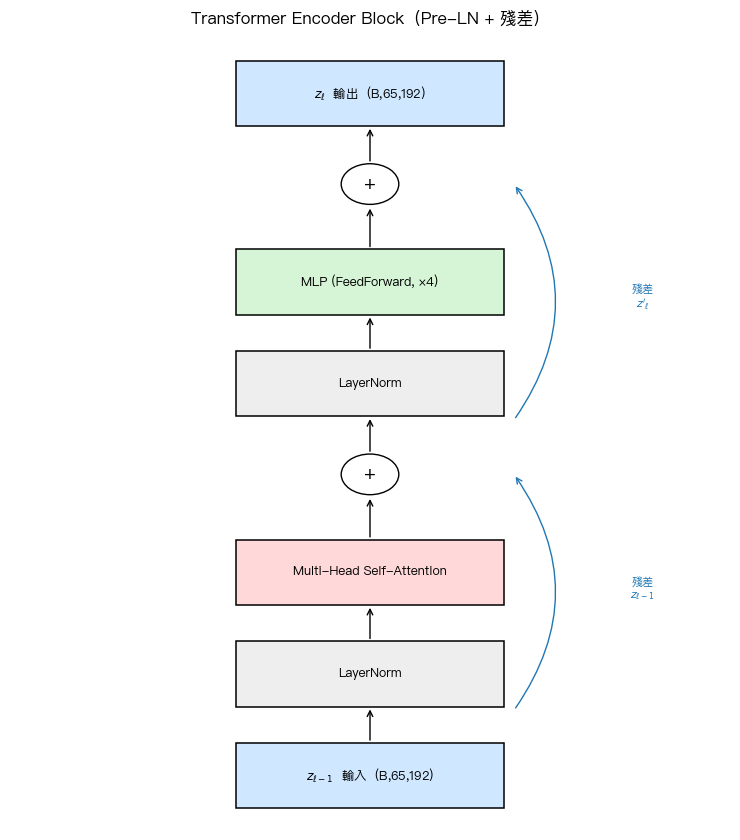

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 8.5)); ax.axis("off")
ax.set_xlim(0, 7); ax.set_ylim(0, 11)

def box(y, t, c, x=2.2, w=2.6, h=0.9, fs=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=c, edgecolor="black", lw=1.1))
    ax.text(x+w/2, y+h/2, t, ha="center", va="center", fontsize=fs)

def arr(y0, y1, x=3.5):
    ax.annotate("", xy=(x, y1), xytext=(x, y0), arrowprops=dict(arrowstyle="->"))

def plus(y):
    ax.add_patch(plt.Circle((3.5, y), 0.28, facecolor="white", edgecolor="black"))
    ax.text(3.5, y, "+", ha="center", va="center", fontsize=14)

# 由下往上：z_{l-1} → LN → MSA → ⊕ → LN → MLP → ⊕ → z_l
# 下標用 mathtext（$...$）渲染，避免中文字型缺下標字形而出現 tofu / glyph warning
box(0.3, rf"$z_{{\ell-1}}$  輸入  (B,{cfg.num_patches+1},{cfg.dim})", "#cfe8ff"); arr(1.2, 1.7)
box(1.7, "LayerNorm", "#eeeeee");                                        arr(2.6, 3.1)
box(3.1, "Multi-Head Self-Attention", "#ffd9d9");                        arr(4.0, 4.6)
plus(4.9);                                                               arr(5.18, 5.7)
box(5.7, "LayerNorm", "#eeeeee");                                        arr(6.6, 7.1)
box(7.1, "MLP (FeedForward, ×%d)" % cfg.mlp_ratio, "#d6f5d6");           arr(8.0, 8.6)
plus(8.9);                                                               arr(9.18, 9.7)
box(9.7, rf"$z_\ell$  輸出  (B,{cfg.num_patches+1},{cfg.dim})", "#cfe8ff")

# 殘差 skip 連線（右側弧線繞過子層）
ax.annotate("", xy=(4.9, 4.9), xytext=(4.9, 1.65),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.35", color="tab:blue"))
ax.text(6.15, 3.2, "殘差\n" r"$z_{\ell-1}$", color="tab:blue", ha="center", fontsize=8)
ax.annotate("", xy=(4.9, 8.9), xytext=(4.9, 5.65),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.35", color="tab:blue"))
ax.text(6.15, 7.2, "殘差\n" r"$z'_\ell$", color="tab:blue", ha="center", fontsize=8)

plt.title("Transformer Encoder Block（Pre-LN + 殘差）", fontsize=12)
plt.tight_layout(); plt.show()

## 9. 組裝完整 ViT
對照論文 Eq. 1–4：
1. **Eq.1** patch 投影 + 前置 `[CLS]` token + 加位置編碼 → $\mathbf{z}_0$
2. **Eq.2–3** $L$ 層 encoder block
3. **Eq.4** 取 `[CLS]` 的輸出做 LayerNorm → 影像表徵 $\mathbf{y}$ → 線性分類頭

關鍵設計：
- **`[CLS]` token**：一個可學習向量，前置到序列最前。它本身不對應任何 patch，但透過注意力「彙整」全圖資訊，最終狀態當作整張圖的表徵（承自 BERT）。*DINO 著名的注意力圖正是來自這個 token。*
- **可學習 1D 位置編碼**：patch 攤平後失去 2D 位置資訊，加上 `pos_embed` 補回。論文發現可學習 1D 編碼已足夠，模型會自己學出 2D 拓樸（之後會驗證，Fig.7 center）。

In [14]:
class ViT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 處理Embedding：Patchify + 線性投影 + [CLS] token + 位置編碼
        self.patch_embed = PatchEmbedding(cfg.image_size, cfg.patch_size, cfg.in_channels, cfg.dim)
        n = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.dim))        # 可學習 [CLS]
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, cfg.dim))    # 可學習 1D 位置編碼 E_pos
        self.dropout = nn.Dropout(cfg.dropout)
        
        # Transformer Encoder Block 堆疊
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(cfg.dim, cfg.heads, cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.depth)])
        self.norm = nn.LayerNorm(cfg.dim)
        self.head = nn.Linear(cfg.dim, cfg.num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init)
    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
    def set_store_attn(self, flag):
        for blk in self.blocks: blk.attn.store_attn = flag
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                       # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)        # (B, 1, D)
        x = torch.cat([cls, x], dim=1) + self.pos_embed   # z_0: (B, N+1, D)
        x = self.dropout(x)
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])                     # 取 [CLS] -> 分類頭

model = ViT(cfg).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"ViT 參數量 / params: {n_params/1e6:.2f} M")

ViT 參數量 / params: 2.69 M


## 10. 形狀追蹤 / Tensor-shape trace
把一個 dummy batch 推過去，印出**每個階段的張量形狀**。這張流程圖（`(B,3,32,32) → (B,65,192) → (B,192) → (B,10)`）就是你之後讀 DINO 程式碼時要複用的心智模型。

In [22]:
@torch.no_grad()
def trace_shapes(model, cfg):
    model.eval()
    x = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=DEVICE)
    print(f"輸入 input              : {tuple(x.shape)}")
    p = model.patch_embed(x);                          print(f"patch embedding         : {tuple(p.shape)}   # (B, N, D)")
    cls = model.cls_token.expand(2, -1, -1)
    z = torch.cat([cls, p], 1) + model.pos_embed;      print(f"+CLS +pos_embed (z_0)   : {tuple(z.shape)}   # (B, N+1, D)")
    for blk in model.blocks: z = blk(z)
    z = model.norm(z);                                 print(f"after {cfg.depth} encoder blocks  : {tuple(z.shape)}")
    print(f"CLS token (y)           : {tuple(z[:,0].shape)}      # (B, D)")
    print(f"logits                  : {tuple(model.head(z[:,0]).shape)}       # (B, num_classes)")

trace_shapes(model, cfg)

輸入 input              : (2, 3, 32, 32)
patch embedding         : (2, 64, 192)   # (B, N, D)
+CLS +pos_embed (z_0)   : (2, 65, 192)   # (B, N+1, D)
after 6 encoder blocks  : (2, 65, 192)
CLS token (y)           : (2, 192)      # (B, D)
logits                  : (2, 10)       # (B, num_classes)


### 10.1 結構總覽圖 / architecture diagram

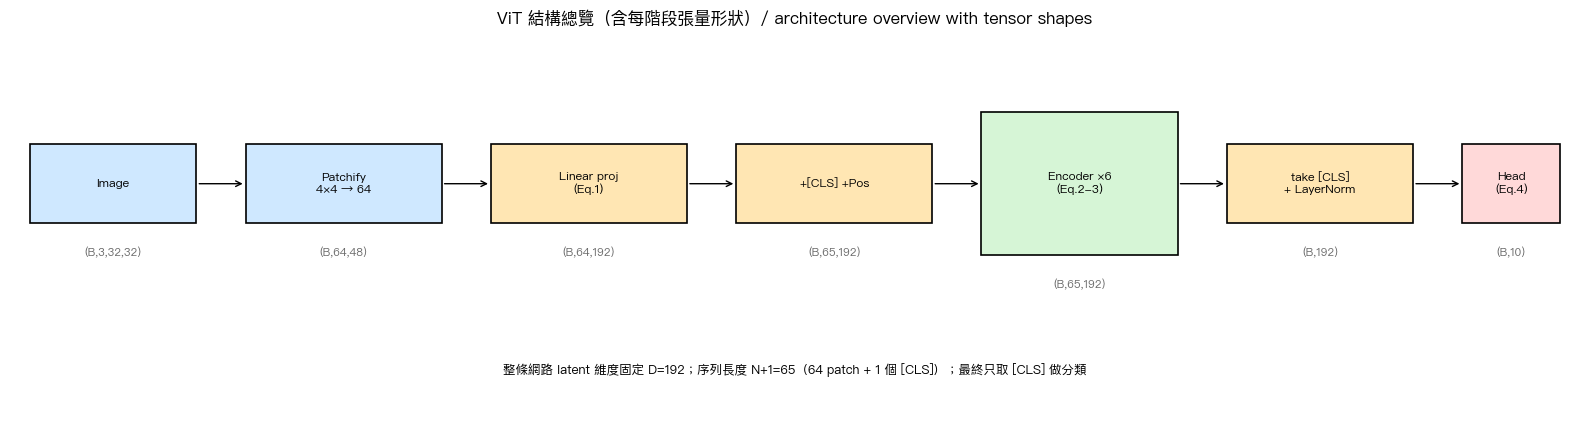

In [24]:
fig, ax = plt.subplots(figsize=(16, 4.5)); ax.axis("off")
ax.set_xlim(0, 16); ax.set_ylim(0, 5)
B, N, D = "B", cfg.num_patches, cfg.dim

def stage(x, w, title, shape, color, y=2.6, h=1.0):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", lw=1.2))
    ax.text(x+w/2, y+h/2, title, ha="center", va="center", fontsize=8.5)
    ax.text(x+w/2, y-0.30, shape, ha="center", va="top", fontsize=8, color="dimgray")

def arr(x0, x1, y=3.1):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle="->"))

stage(0.2,  1.7, "Image",                                f"(B,3,{cfg.image_size},{cfg.image_size})", "#cfe8ff"); arr(1.9, 2.4)
stage(2.4,  2.0, f"Patchify\n{cfg.patch_size}×{cfg.patch_size} → {N}",   f"(B,{N},{cfg.patch_size**2*cfg.in_channels})", "#cfe8ff"); arr(4.4, 4.9)
stage(4.9,  2.0, "Linear proj\n(Eq.1)",                   f"(B,{N},{D})",   "#ffe6b3"); arr(6.9, 7.4)
stage(7.4,  2.0, "+[CLS] +Pos",                          f"(B,{N+1},{D})", "#ffe6b3"); arr(9.4, 9.9)
stage(9.9,  2.0, f"Encoder ×{cfg.depth}\n(Eq.2-3)",      f"(B,{N+1},{D})", "#d6f5d6", y=2.2, h=1.8); arr(11.9, 12.4)
stage(12.4, 1.9, "take [CLS]\n+ LayerNorm",              f"(B,{D})",       "#ffe6b3"); arr(14.3, 14.8)
stage(14.8, 1.0, "Head\n(Eq.4)",                         f"(B,{cfg.num_classes})", "#ffd9d9")

ax.text(8, 0.7, "整條網路 latent 維度固定 D=%d；序列長度 N+1=%d（%d patch + 1 個 [CLS]）；最終只取 [CLS] 做分類"
        % (D, N+1, N), ha="center", fontsize=9, color="black")
plt.title("ViT 結構總覽（含每階段張量形狀）/ architecture overview with tensor shapes", fontsize=12)
plt.tight_layout(); plt.show()

## 11. 訓練設定 / Training setup
- **Optimizer**：AdamW（論文用 Adam + 高 weight decay；AdamW 是其現代等價版，把 weight decay 與梯度更新解耦）。
- **學習率排程**：線性 **warmup** → **cosine decay**（論文 App. B.1；也是 DeiT/DINO 的標準配方）。warmup 讓初期不穩的注意力先「暖機」。
- **Loss**：CrossEntropy + **label smoothing 0.1**（軟化標籤，抑制過度自信、改善泛化）。

In [25]:
criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

steps_per_epoch = len(train_loader)
total_steps  = cfg.epochs * steps_per_epoch
warmup_steps = cfg.warmup_epochs * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:                    # 線性 warmup
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))   # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"steps/epoch={steps_per_epoch} | total={total_steps} | warmup={warmup_steps}")

steps/epoch=390 | total=19500 | warmup=1950


### 11.1 訓練迴圈 / training loop
> 想跑完整訓練：把 `cfg.epochs` 調到 50（預設）。想快速看流程：改小即可。訓練完成的權重會存成 `vit_cifar10.pt`，後面的分析會用到訓練後的模型。

In [27]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct = total = 0; loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item(); total += x.size(0)
    return loss_sum/total, correct/total

history = {"train_loss":[], "test_loss":[], "test_acc":[], "lr":[]}

def train():
    for epoch in range(cfg.epochs):
        model.train(); 
        t0 = time.time(); 
        run_loss = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward(); optimizer.step(); scheduler.step()
            run_loss += loss.item()*x.size(0); total += x.size(0)
        te_loss, te_acc = evaluate(model, test_loader)   # 每個 epoch 在測試集評估
        tr_loss = run_loss/total
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss); history["test_acc"].append(te_acc)
        history["lr"].append(scheduler.get_last_lr()[0])
        print(f"epoch {epoch+1:3d}/{cfg.epochs} | lr {history['lr'][-1]:.2e} | "
              f"train_loss {tr_loss:.3f} | test {te_loss:.3f}/{te_acc:.3f} | {time.time()-t0:.1f}s")

train()
torch.save(model.state_dict(), "vit_cifar10.pt")
print("saved -> vit_cifar10.pt")

epoch   1/50 | lr 6.02e-05 | train_loss 2.149 | test 1.990/0.297 | 90.8s
epoch   2/50 | lr 1.20e-04 | train_loss 2.003 | test 1.862/0.354 | 101.5s
epoch   3/50 | lr 1.80e-04 | train_loss 1.844 | test 1.695/0.430 | 114.7s
epoch   4/50 | lr 2.40e-04 | train_loss 1.742 | test 1.567/0.504 | 111.3s
epoch   5/50 | lr 3.00e-04 | train_loss 1.683 | test 1.562/0.509 | 116.8s
epoch   6/50 | lr 3.00e-04 | train_loss 1.633 | test 1.473/0.543 | 120.5s
epoch   7/50 | lr 2.99e-04 | train_loss 1.588 | test 1.423/0.577 | 130.7s
epoch   8/50 | lr 2.97e-04 | train_loss 1.556 | test 1.393/0.587 | 115.8s
epoch   9/50 | lr 2.94e-04 | train_loss 1.524 | test 1.399/0.594 | 118.6s
epoch  10/50 | lr 2.91e-04 | train_loss 1.492 | test 1.364/0.604 | 124.0s
epoch  11/50 | lr 2.87e-04 | train_loss 1.457 | test 1.330/0.617 | 117.6s
epoch  12/50 | lr 2.82e-04 | train_loss 1.428 | test 1.270/0.644 | 122.7s
epoch  13/50 | lr 2.77e-04 | train_loss 1.408 | test 1.270/0.649 | 128.5s
epoch  14/50 | lr 2.71e-04 | train_loss

### 11.2 訓練曲線 / curves

NameError: name 'history' is not defined

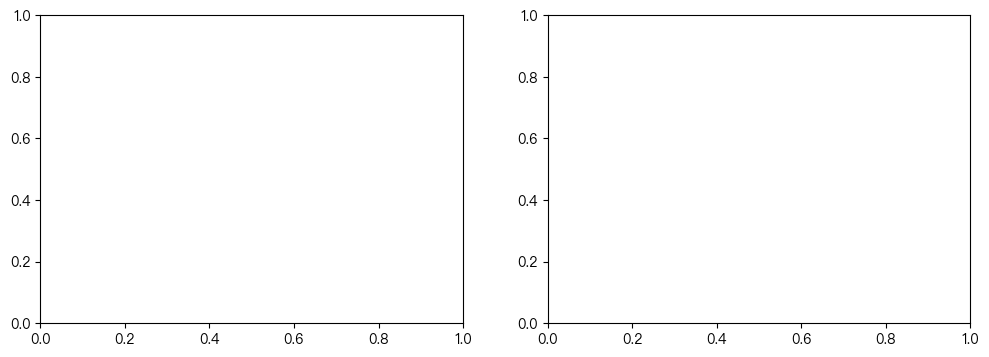

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12,4))
a1.plot(history["train_loss"], label="train loss"); a1.plot(history["test_loss"], label="test loss")
a1.set_title("Loss"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(history["test_acc"], label="test acc", color="tab:green")
a2.set_title("Test accuracy"); a2.set_xlabel("epoch"); a2.legend()
plt.tight_layout(); plt.show()

### 11.3 範例預測（含信心分數）/ predictions

In [ ]:
model.eval()
imgs, labels = next(iter(test_loader))
with torch.no_grad():
    probs = model(imgs.to(DEVICE)).softmax(1).cpu()
conf, pred = probs.max(1)
fig, axes = plt.subplots(2, 8, figsize=(15,4))
for ax, img, lb, pr, cf in zip(axes.flatten(), imgs, labels, pred, conf):
    ax.imshow(denorm(img)); ax.axis("off")
    ax.set_title(f"{CLASSES[pr]} {cf*100:.0f}%", fontsize=9,
                 color=("green" if pr==lb else "red"))
plt.suptitle("預測（綠=正確, 紅=錯誤）/ predictions"); plt.tight_layout(); plt.show()

## 12. 解析 Vision Transformer（重現論文 Fig 6 & 7）
以下分析窺探 ViT 內部表徵。**注意**：部分圖（位置編碼相似度、注意力距離）需要**充分訓練**的模型才會出現清楚的結構；若只跑了少量 epoch，看起來會比較雜訊。

### 12.1 Attention Rollout（Fig. 6）：`[CLS]` 注意到哪裡
單層注意力不足以反映資訊如何跨層流動。**Attention rollout**（Abnar & Zuidema, 2020）把每層注意力（含殘差的恆等項）逐層相乘，近似從輸入到輸出的資訊流。我們取 `[CLS]` 對各 patch 的 rollout 權重，reshape 回 8×8 疊在原圖上——這正是 **DINO 自監督注意力圖**的前身。

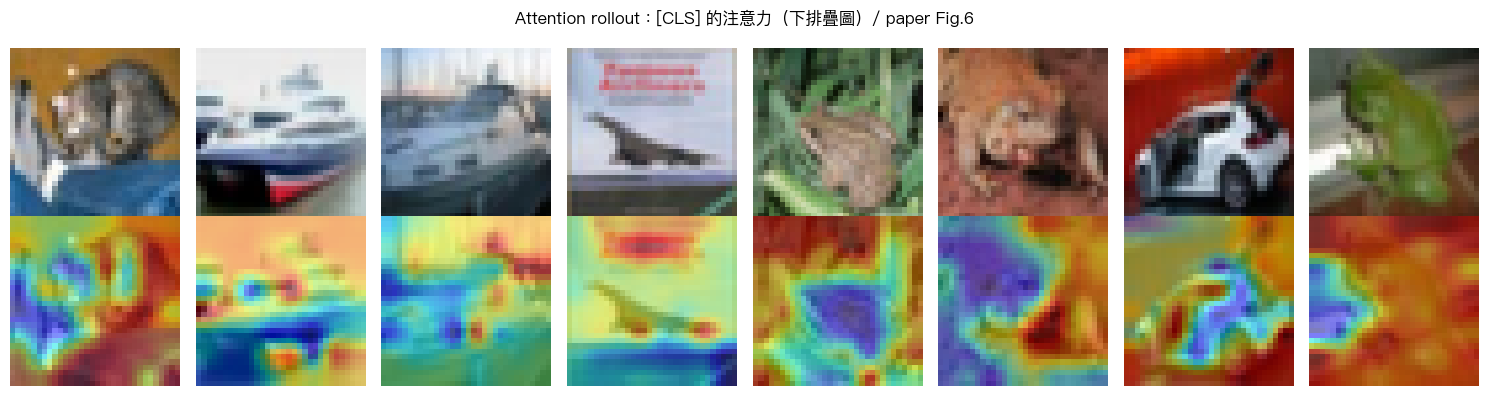

In [16]:
def get_attentions(model, x):
    model.eval(); model.set_store_attn(True)
    with torch.no_grad(): _ = model(x)
    attns = [blk.attn.last_attn for blk in model.blocks]   # 每層 (B, heads, N, N)
    model.set_store_attn(False)
    return attns

def attention_rollout(attns):
    # 逐層 (A + I) 後做 row-normalize，再相乘
    result = None
    for a in attns:
        a = a.mean(1)                                   # 平均所有 head -> (B, N, N)
        a = a + torch.eye(a.size(-1), device=a.device)
        a = a / a.sum(-1, keepdim=True)
        result = a if result is None else a @ result
    return result

imgs, labels = next(iter(test_loader))
attns = get_attentions(model, imgs[:8].to(DEVICE))
roll  = attention_rollout(attns)
cls_to_patch = roll[:, 0, 1:]                            # CLS 對各 patch (8, 64)
maps = cls_to_patch.reshape(-1, cfg.grid, cfg.grid).cpu()
fig, axes = plt.subplots(2, 8, figsize=(15,4))
for i in range(8):
    axes[0,i].imshow(denorm(imgs[i])); axes[0,i].axis("off")
    m = maps[i]; m = (m - m.min())/(m.max()-m.min()+1e-8)
    m = F.interpolate(m[None,None], size=32, mode="bilinear", align_corners=False)[0,0]
    axes[1,i].imshow(denorm(imgs[i])); axes[1,i].imshow(m, cmap="jet", alpha=0.5); axes[1,i].axis("off")
axes[0,0].set_ylabel("input");
plt.suptitle("Attention rollout：[CLS] 的注意力（下排疊圖）/ paper Fig.6"); plt.tight_layout(); plt.show()

### 12.2 線性嵌入濾波器（Fig. 7 left）
Patch embedding 的卷積權重形狀是 `(D, 3, 4, 4)`——可視為 $D$ 個 RGB 濾波器。對它做 PCA，前幾個主成分常呈現類似 Gabor / 顏色對比的基底函數，說明第一層學到 patch 內細結構的低維表示。

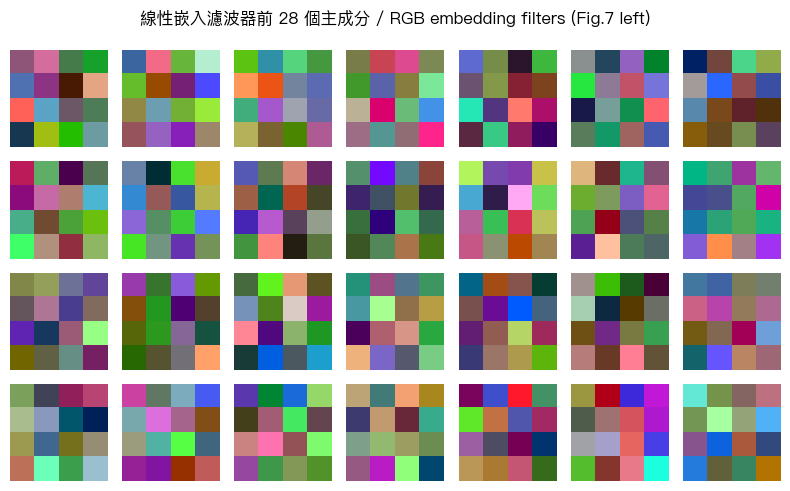

In [17]:
from sklearn.decomposition import PCA
W = model.patch_embed.proj.weight.detach().cpu()         # (D, 3, P, P)
D = W.shape[0]; flat = W.reshape(D, -1).numpy()
k = min(28, D, flat.shape[1])
comps = PCA(n_components=k).fit(flat).components_.reshape(k, 3, cfg.patch_size, cfg.patch_size)
fig, axes = plt.subplots(4, 7, figsize=(8,5))
for i, ax in enumerate(axes.flatten()):
    if i < k:
        c = comps[i].transpose(1,2,0); c = (c-c.min())/(c.max()-c.min()+1e-8)
        ax.imshow(c)
    ax.axis("off")
plt.suptitle("線性嵌入濾波器前 28 個主成分 / RGB embedding filters (Fig.7 left)"); plt.tight_layout(); plt.show()

### 12.3 位置編碼相似度（Fig. 7 center）
每個 patch 位置有一個學到的 `pos_embed` 向量。計算「某位置 vs 所有位置」的餘弦相似度並 reshape 回 8×8：**充分訓練後**，越接近的位置相似度越高，且呈現行/列結構——代表模型**自己從 1D 編碼學出了 2D 影像拓樸**，這解釋了為何更複雜的 2D 編碼幫助不大。

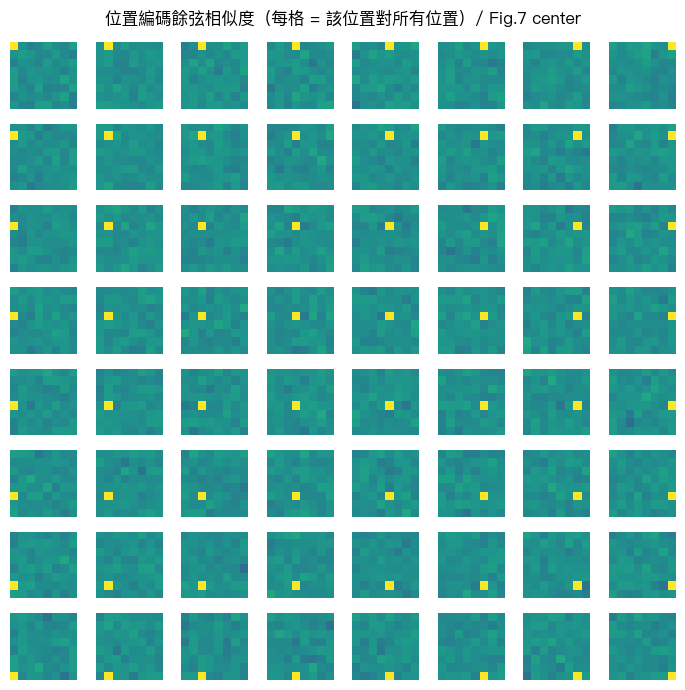

In [18]:
pos = model.pos_embed.detach().cpu()[0, 1:]              # (N, D) 去掉 CLS
pos = F.normalize(pos, dim=1)
G = cfg.grid
sim = (pos @ pos.t()).reshape(G, G, G, G)
fig, axes = plt.subplots(G, G, figsize=(7,7))
for i in range(G):
    for j in range(G):
        axes[i,j].imshow(sim[i,j], cmap="viridis", vmin=-1, vmax=1); axes[i,j].axis("off")
plt.suptitle("位置編碼餘弦相似度（每格 = 該位置對所有位置）/ Fig.7 center"); plt.tight_layout(); plt.show()

### 12.4 平均注意力距離 vs 深度（Fig. 7 right）
對每個 head，計算「注意力加權的 patch 間像素距離」平均——類似 CNN 的感受野大小。論文發現：**淺層**就有些 head 看很遠（全域），這是 CNN 做不到的；隨深度增加，注意力距離整體變大。

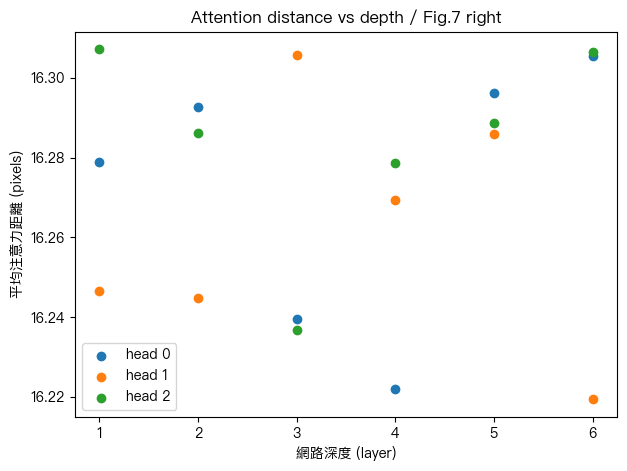

In [19]:
coords = np.stack(np.meshgrid(np.arange(G), np.arange(G), indexing="ij"), -1).reshape(-1,2) * cfg.patch_size
dist_t = torch.tensor(np.linalg.norm(coords[:,None,:]-coords[None,:,:], axis=-1), dtype=torch.float32)
imgs, _ = next(iter(test_loader))
attns = get_attentions(model, imgs[:64].to(DEVICE))
mean_dist = np.zeros((cfg.depth, cfg.heads))
for l, a in enumerate(attns):
    a = a[:, :, 1:, 1:].mean(0).cpu()        # 去掉 CLS 行列, 對 batch 平均 -> (heads, N, N)
    mean_dist[l] = (a * dist_t).sum(-1).mean(-1).numpy()
plt.figure(figsize=(7,5))
for h in range(cfg.heads):
    plt.scatter(np.arange(1, cfg.depth+1), mean_dist[:,h], label=f"head {h}")
plt.xlabel("網路深度 (layer)"); plt.ylabel("平均注意力距離 (pixels)")
plt.title("Attention distance vs depth / Fig.7 right"); plt.legend(); plt.show()

## 13. 與 `vit-pytorch` 對照 / sanity check
拿社群常用的 `SimpleViT` 對照我們的實作。注意 **`SimpleViT` 的設計選擇與論文/我們不同**：它用**全域平均池化 (GAP)** 取代 `[CLS]`、用**固定 sin-cos 位置編碼**取代可學習編碼、且無 dropout。GAP 版在小資料上常更好訓練，但**沒有 `[CLS]` 注意力可看**——這正是 DINO 保留 `[CLS]` 的原因。

In [ ]:
from vit_pytorch import SimpleViT
sv = SimpleViT(image_size=32, patch_size=4, num_classes=10, dim=192, depth=6, heads=3, mlp_dim=768)
sv_params = sum(p.numel() for p in sv.parameters())
print("SimpleViT 輸出:", tuple(sv(torch.randn(2,3,32,32)).shape), f"| 參數量 {sv_params/1e6:.2f} M")
print(f"我們的 ViT 參數量: {n_params/1e6:.2f} M")
print("差異：SimpleViT = GAP + 固定 sin-cos 位置編碼 + 無 [CLS] + 無 dropout")

## 14. 總結與下一步 / Summary & next steps
**你手刻了什麼**：PatchEmbedding → `[CLS]`+位置編碼 → Multi-Head Self-Attention → Pre-LN Encoder → `[CLS]` 分類頭，完全對應論文 Eq. 1–4，並重現了 Fig 6 & 7 的分析。

**帶走的核心觀念**
1. **圖像 = patch 序列**：ViT 把視覺問題變成序列建模，幾乎照搬 NLP 的 Transformer。
2. **少歸納偏好 = 資料飢渴**：沒有局部性/平移等變性先驗，從零訓練在小資料上吃虧（本筆記本親身驗證）——這就是大規模（自）監督預訓練的動機。
3. **`[CLS]` 注意力 = 可解釋性入口**：rollout 圖顯示模型關注語意相關區域，是 DINO 注意力圖的前身。

**下一步（另一本筆記本）→ DINO / cellDINO**
- 同一個 ViT backbone，把監督式分類頭換成**自監督**目標（學生/教師網路 + 多視角裁剪 + 中心化/銳化），不需標籤就能學出強表徵。
- DINO 的注意力圖能**無監督分割物件**——直接建立在本筆記本的 `[CLS]`-attention 機制上。
- cellDINO：把同套自監督方法搬到細胞/顯微影像領域。